
-# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?



In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv("Employee_productivity.csv")
df.head()

,HoursWorked,FocusScore,ProductivityScore,Department,YearsAtCompany,TeamMeetingsPerWeek,DeskLocation
0,42.4,6.3,3127.96,Engineering,17,0,Open Plan
1,34.0,7.2,4742.60,HR,8,6,Private Office
2,47.2,5.6,2044.73,Sales,15,3,Remote
3,38.4,9.0,5818.92,HR,5,6,Private Office
4,36.4,2.5,1841.31,Sales,9,6,Remote


YearsAtCompany : Regression value R2 0.002


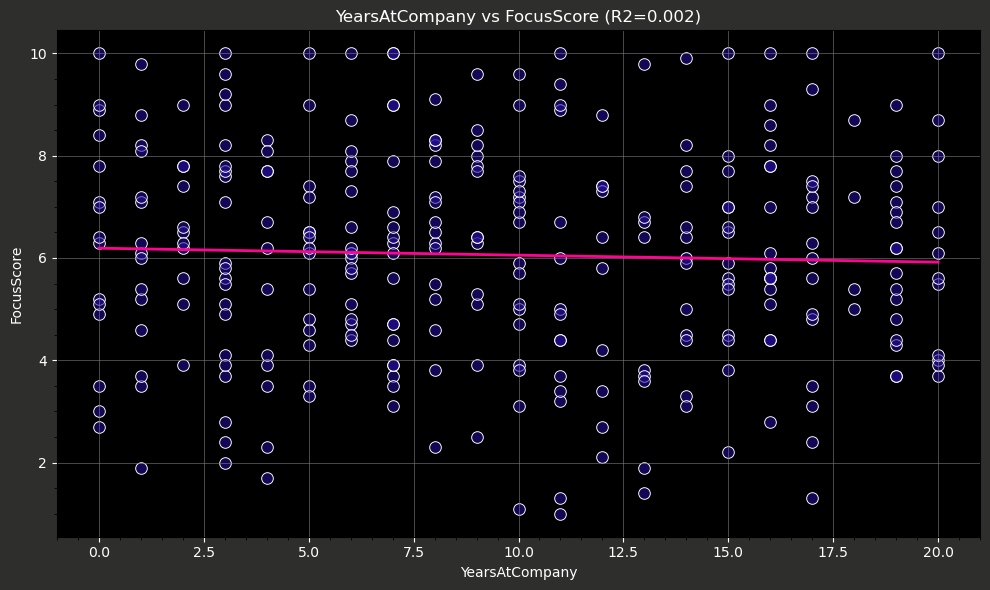

HoursWorked : Regression value R2 0.002


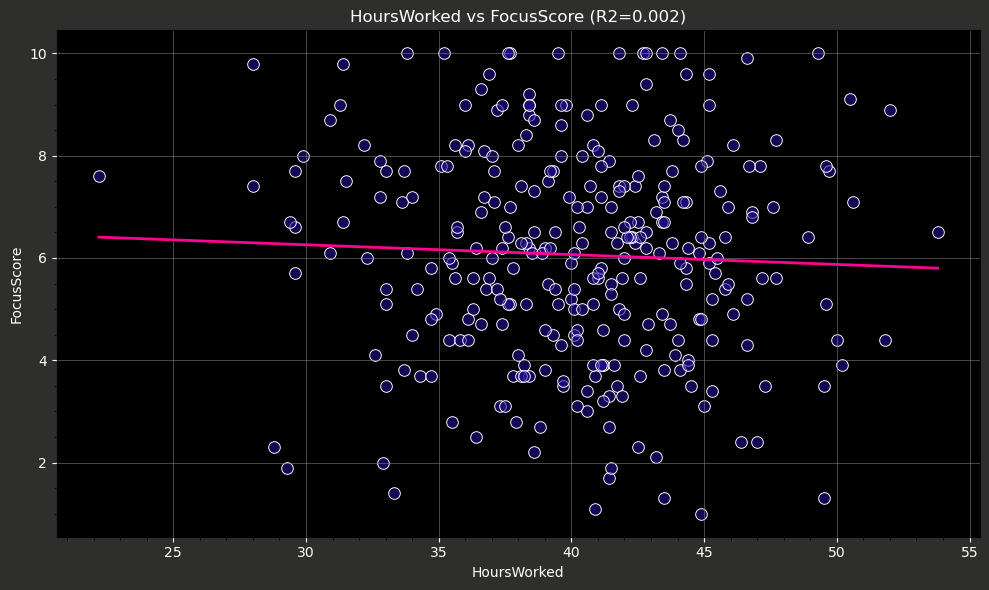

In [ ]:

features = ["YearsAtCompany", "HoursWorked"]


fig_bg = '#2e2e2d'
ax_bg = 'black'
point_color = "#230e9692"
line_color = "#ff0492ff"


for feature in features:

    data = df[[feature, "FocusScore"]].dropna()

    X = data[[feature]]
    y = data["FocusScore"]


    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    print(feature,f": Regression value R2 {r2:.3f}" )

    fig, ax = plt.subplots(figsize=(10,6))
    sns.scatterplot(x=feature, y="FocusScore", data=data,
                    color=point_color, edgecolor="white", s=70, ax=ax)

    sns.lineplot(x=data[feature], y=y_pred,
                 color=line_color, linewidth=2, ax=ax)

    fig.set_facecolor(fig_bg)
    ax.set_facecolor(ax_bg)
    ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
    ax.grid(True, axis='x', linestyle='-', linewidth=.4, color='gray')
    ax.minorticks_on()
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    ax.set_title(f"{feature} vs FocusScore (R2={r2:.3f})", color='white')
    ax.set_xlabel(feature, color='white')
    ax.set_ylabel("FocusScore", color='white')

    plt.tight_layout()
    plt.show()

YearsAtCompany : Regression value R2 0.000


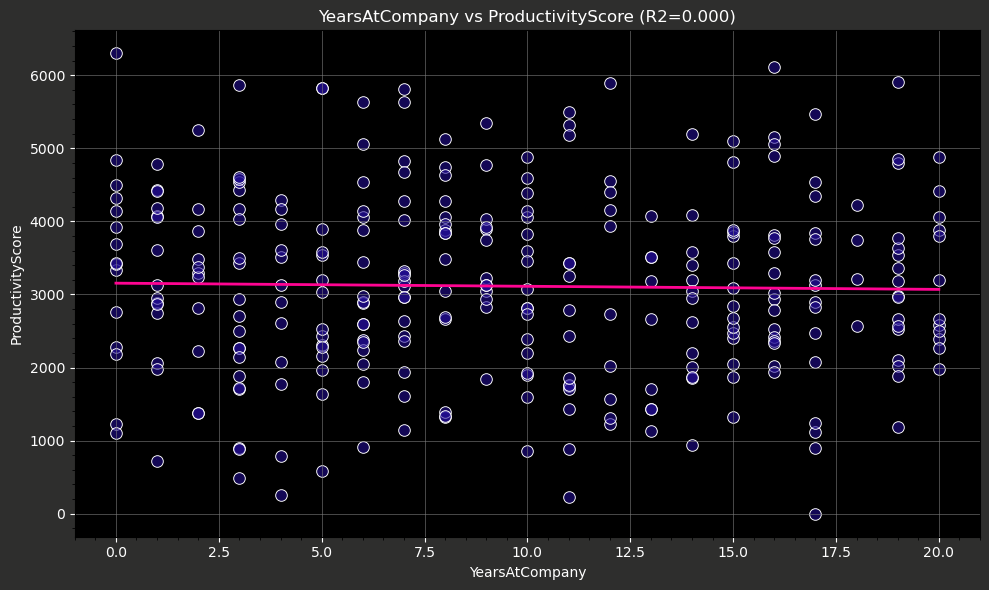

HoursWorked : Regression value R2 0.003


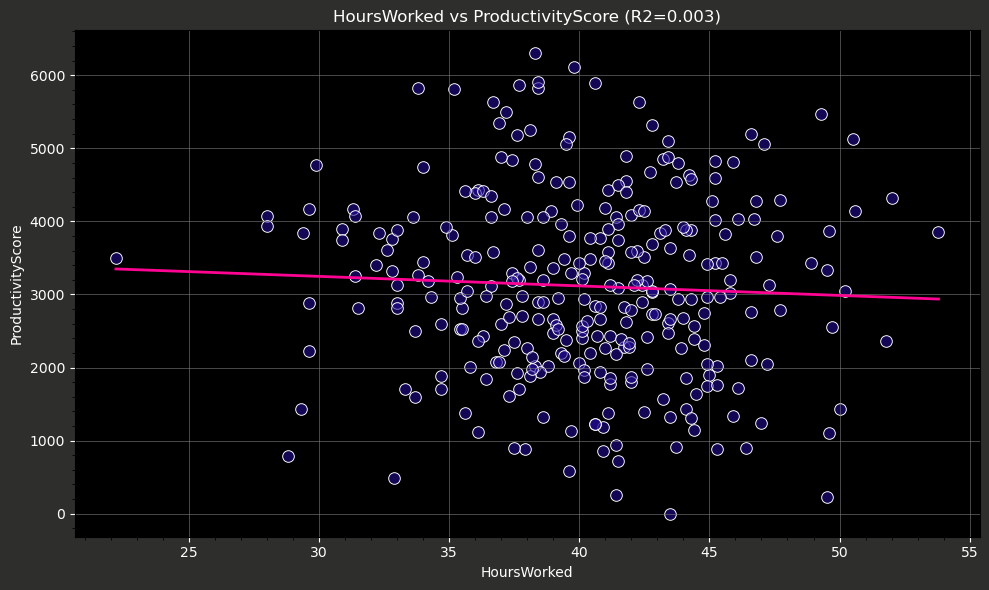

FocusScore : Regression value R2 0.678


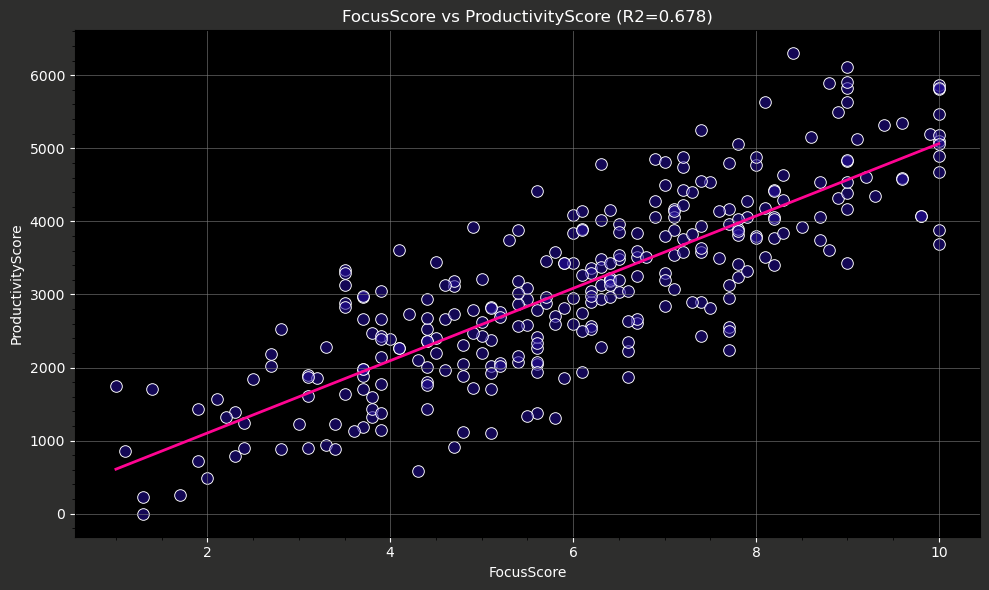

In [ ]:

features = ["YearsAtCompany", "HoursWorked", "FocusScore"]


fig_bg = '#2e2e2d'
ax_bg = 'black'
point_color = "#230e9692"
line_color = "#ff0492ff"


for feature in features:

    data = df[[feature, "ProductivityScore"]].dropna()


    X = data[[feature]]
    y = data["ProductivityScore"]


    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    print(feature,f": Regression value R2 {r2:.3f}" )


    fig, ax = plt.subplots(figsize=(10,6))
    sns.scatterplot(x=feature, y="ProductivityScore", data=data,
                    color=point_color, edgecolor="white", s=70, ax=ax)


    sns.lineplot(x=data[feature], y=y_pred,
                 color=line_color, linewidth=2, ax=ax)


    fig.set_facecolor(fig_bg)
    ax.set_facecolor(ax_bg)
    ax.grid(True, axis='y', linestyle='-', linewidth=.4, color='gray')
    ax.grid(True, axis='x', linestyle='-', linewidth=.4, color='gray')
    ax.minorticks_on()
    ax.tick_params(axis='x', colors='white')
    ax.tick_params(axis='y', colors='white')
    ax.set_title(f"{feature} vs ProductivityScore (R2={r2:.3f})", color='white')
    ax.set_xlabel(feature, color='white')
    ax.set_ylabel("ProductivityScore", color='white')

    plt.tight_layout()
    plt.show()

Multiple Regression R²: 0.679


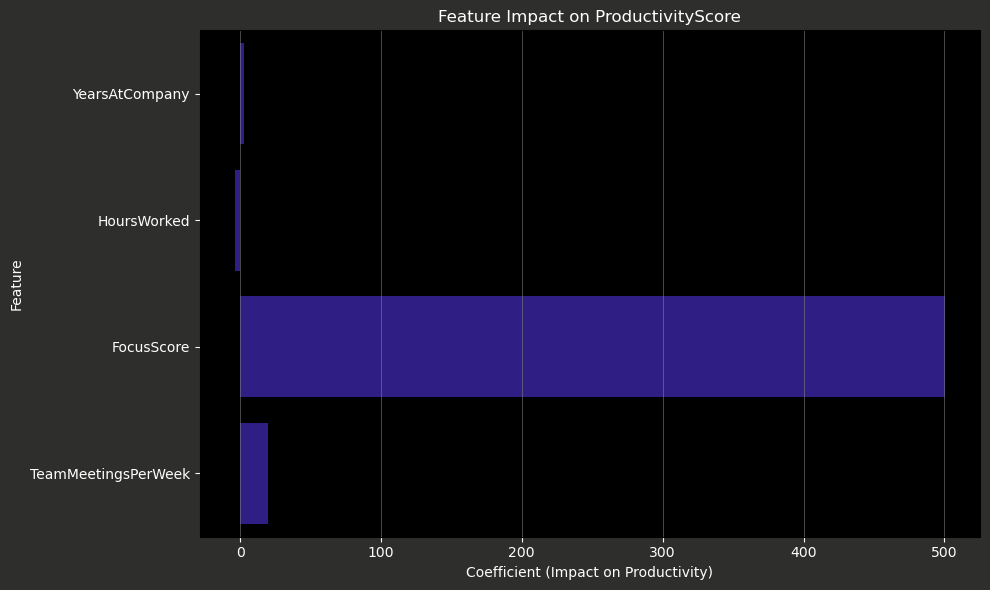

In [ ]:

features_all = ["YearsAtCompany", "HoursWorked", "FocusScore", "TeamMeetingsPerWeek"]

X = df[features_all]
y = df["ProductivityScore"]


model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


r2 = r2_score(y, y_pred)
print(f"Multiple Regression: {r2:.3f}")


coef_df = pd.DataFrame({"Feature": features_all, "Coefficient": model.coef_})


fig_bg = '#2e2e2d'
ax_bg = 'black'
bar_color = "#230e9692"

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", color=bar_color, ax=ax)


fig.set_facecolor(fig_bg)
ax.set_facecolor(ax_bg)
ax.grid(True, axis='x', linestyle='-', linewidth=.4, color='gray')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.set_title("Feature Impact on ProductivityScore", color='white')
ax.set_xlabel("Coefficient (Impact on Productivity)", color='white')
ax.set_ylabel("Feature", color='white')

plt.tight_layout()
plt.show()


Multiple Regression R² (all features): 0.685


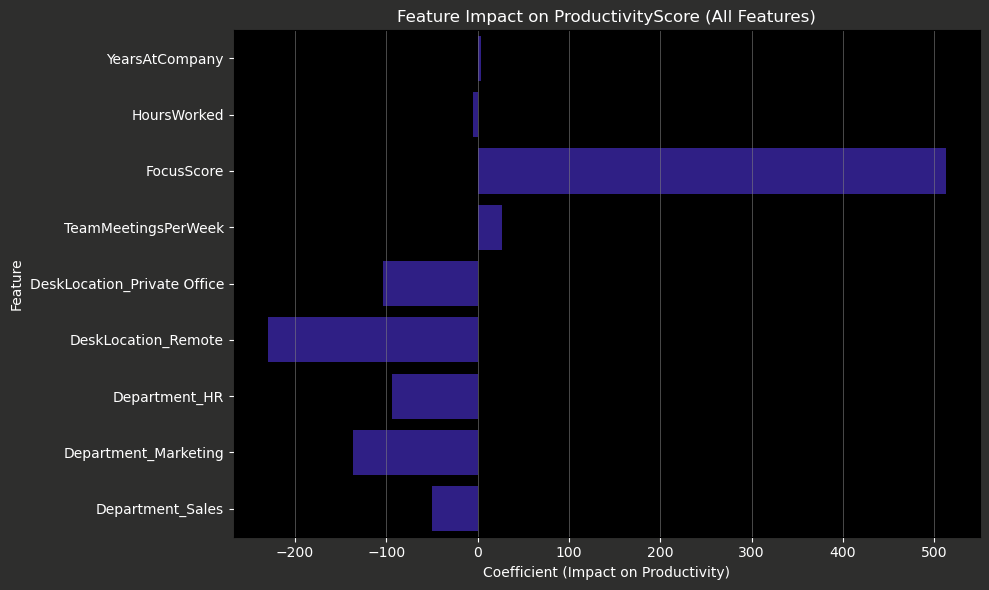

In [ ]:

numeric_features = ["YearsAtCompany", "HoursWorked", "FocusScore", "TeamMeetingsPerWeek"]


df_encoded = pd.get_dummies(df, columns=["DeskLocation", "Department"], drop_first=True)


features_all = numeric_features + [col for col in df_encoded.columns if "DeskLocation_" in col or "Department_" in col]

X = df_encoded[features_all].dropna()
y = df_encoded["ProductivityScore"].loc[X.index]

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)


r2 = r2_score(y, y_pred)
print(f"Multiple Regression R² (all features): {r2:.3f}")


coef_df = pd.DataFrame({"Feature": features_all, "Coefficient": model.coef_})


fig_bg = '#2e2e2d'
ax_bg = 'black'
bar_color = "#230e9692"

fig, ax = plt.subplots(figsize=(10,6))
sns.barplot(data=coef_df, x="Coefficient", y="Feature", color=bar_color, ax=ax)


fig.set_facecolor(fig_bg)
ax.set_facecolor(ax_bg)
ax.grid(True, axis='x', linestyle='-', linewidth=.4, color='gray')
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')
ax.set_title("Feature Impact on ProductivityScore (All Features)", color='white')
ax.set_xlabel("Coefficient (Impact on Productivity)", color='white')
ax.set_ylabel("Feature", color='white')

plt.tight_layout()
plt.show()



Focus Score is by far the strongest predictor of productivity Neither Years at Company nor Hours Worked explain productivity in any meaningful way. Even when adding other factors like meetings per week, desk location, or department, the model only improves slightly.

This suggests that an employee’s ability to focus is the key driver of productivity, while simply working more hours or being more experienced at the company does not guarantee higher productivity.